# CV Lab 8

## 1) using cifar10 data set build convolutional neural network

In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf
import math
import numpy as np
import matplotlib.pyplot as plt
import time

## Importing and exploring dataset

In [2]:
dataset, metadata = tfds.load('cifar10', as_supervised=True, with_info=True)
train, test = dataset['train'], dataset['test']

In [3]:
print(metadata.features['label'].names)
print(len(metadata.features['label'].names))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


In [4]:
print (train)
print(len(train))
print(len(test))

<_PrefetchDataset element_spec=(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
50000
10000


## Normalizing images' values for better calculation efficiency

In [5]:
def normalize(images, labels):
  images = tf.cast(images, tf.float32)
  images /= 255
  return images, labels

train =  train.map(normalize)
test  =  test.map(normalize)

#train =  train.cache()
#test  =  test.cache()

## Exploring images after normalizing

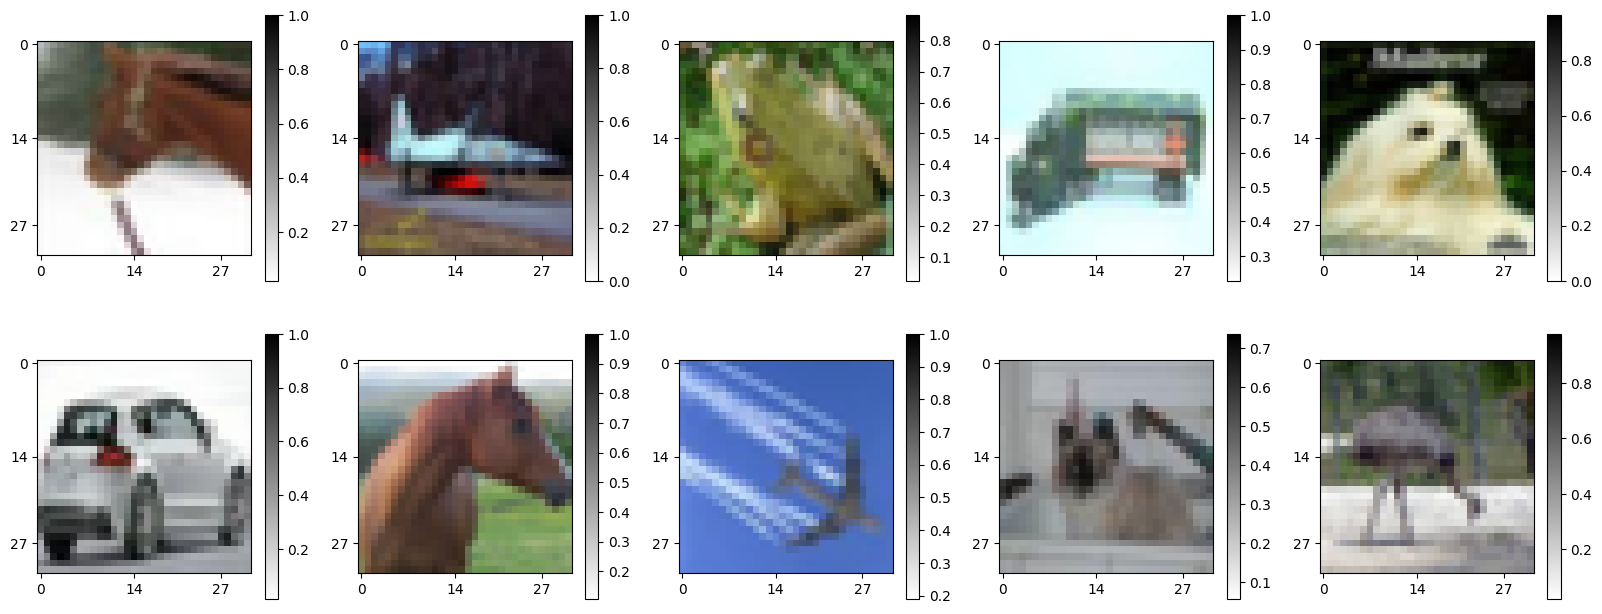

In [7]:
plt.figure(figsize=(20,20))

i = 0

for (image, label) in test.take(10):
    plt.subplot(5,5,i+1)
    plt.xticks([0,14,27])
    plt.yticks([0,14,27])
    plt.imshow(image, cmap=plt.cm.binary)
    plt.colorbar()
    i += 1

plt.show()

## Building CNN Model

In [8]:
batchSize = 64

train = train.cache().repeat().shuffle(50000).batch(batchSize)
test = test.cache().batch(batchSize)

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu, input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation=tf.nn.relu),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),

    tf.keras.layers.Dense(10)
])

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 4, 4, 128)         0

In [12]:
t = time.time()
hist = model.fit(train, epochs=15, steps_per_epoch=math.ceil(50000/batchSize))
print (str.format("Training took: {:0.2f} Sec", time.time() - t))
model.save('cifar10_cnn.h5')

Epoch 1/15
782/782 [==============================] - 61s 74ms/step - loss: 1.4549 - accuracy: 0.4729
Epoch 2/15
782/782 [==============================] - 58s 75ms/step - loss: 1.0291 - accuracy: 0.6367
Epoch 3/15
782/782 [==============================] - 60s 76ms/step - loss: 0.8563 - accuracy: 0.7025
Epoch 4/15
782/782 [==============================] - 60s 77ms/step - loss: 0.7421 - accuracy: 0.7423
Epoch 5/15
782/782 [==============================] - 63s 81ms/step - loss: 0.6585 - accuracy: 0.7735
Epoch 6/15
782/782 [==============================] - 62s 79ms/step - loss: 0.5921 - accuracy: 0.7937
Epoch 7/15
782/782 [==============================] - 60s 77ms/step - loss: 0.5196 - accuracy: 0.8192
Epoch 8/15
782/782 [==============================] - 60s 76ms/step - loss: 0.4619 - accuracy: 0.8391
Epoch 9/15
782/782 [==============================] - 59s 76ms/step - loss: 0.4113 - accuracy: 0.8563
Epoch 10/15
782/782 [==============================] - 61s 78ms/step - loss: 0.360

C:\Users\osama zidan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluating model

In [13]:
test_loss, test_accuracy = model.evaluate(test, steps=math.ceil(10000/batchSize))
print('Loss on test dataset:', test_loss)
print('Accuracy on test dataset:', test_accuracy)

157/157 [==============================] - 3s 16ms/step - loss: 1.1864 - accuracy: 0.7413
Loss on test dataset: 1.1864160299301147
Accuracy on test dataset: 0.7412999868392944


In [14]:
hist.history['accuracy']

[0.4728660583496094,
 0.636688768863678,
 0.7025255560874939,
 0.7423073649406433,
 0.7734574675559998,
 0.7937180399894714,
 0.8191936016082764,
 0.839054524898529,
 0.8562979698181152,
 0.8742806911468506,
 0.8892862796783447,
 0.9041720032691956,
 0.9182385206222534,
 0.9275895357131958,
 0.9381194114685059]

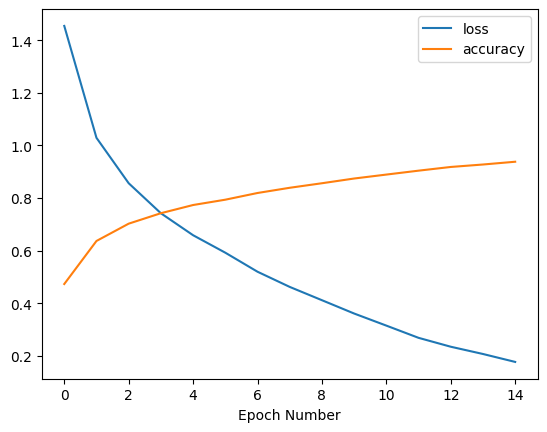

In [15]:
plt.xlabel('Epoch Number')
plt.plot(hist.history['loss'] ,label='loss')
plt.plot(hist.history['accuracy'] ,label='accuracy')
plt.legend()

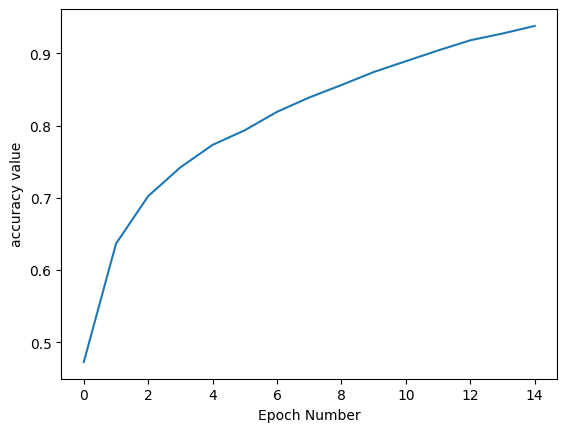

In [16]:
plt.xlabel('Epoch Number')
plt.ylabel("accuracy value")
plt.plot(hist.history['accuracy']);

## Confusion Matrix

157/157 [==============================] - 3s 18ms/step


(<Figure size 800x800 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

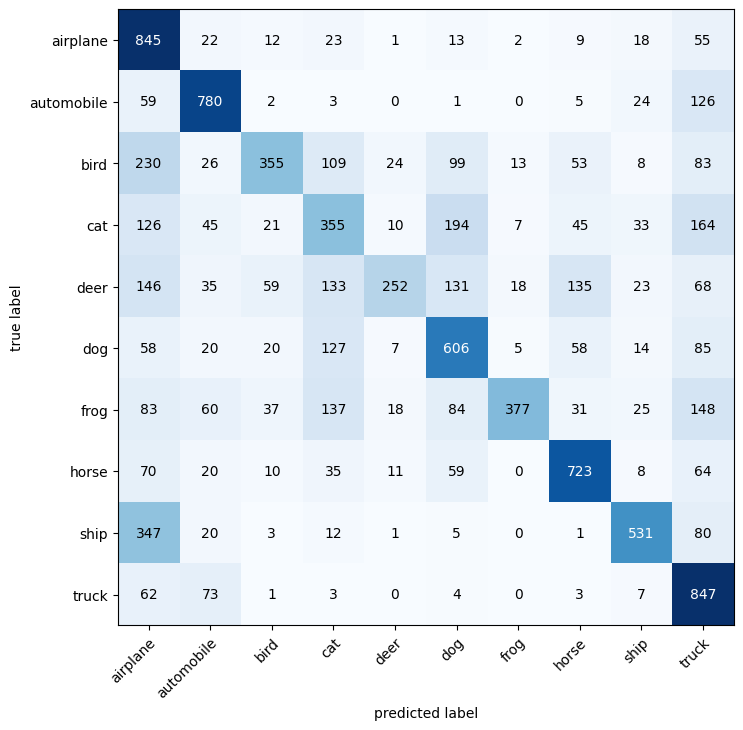

In [17]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

dataset, metadata = tfds.load('cifar10', as_supervised=True, with_info=True)
train, test = dataset['train'], dataset['test']

validation_batches = test.batch(batchSize)
pred = model.predict(validation_batches)
pred = np.argmax(pred,axis=1)
true = tf.concat([y for x,y in validation_batches],axis=0)

mat = confusion_matrix(true,pred)
plot_confusion_matrix(conf_mat=mat,figsize=(8,8), class_names=metadata.features['label'].names)

## Exploring predictions and comparing them to true labels

157/157 [==============================] - 2s 13ms/step


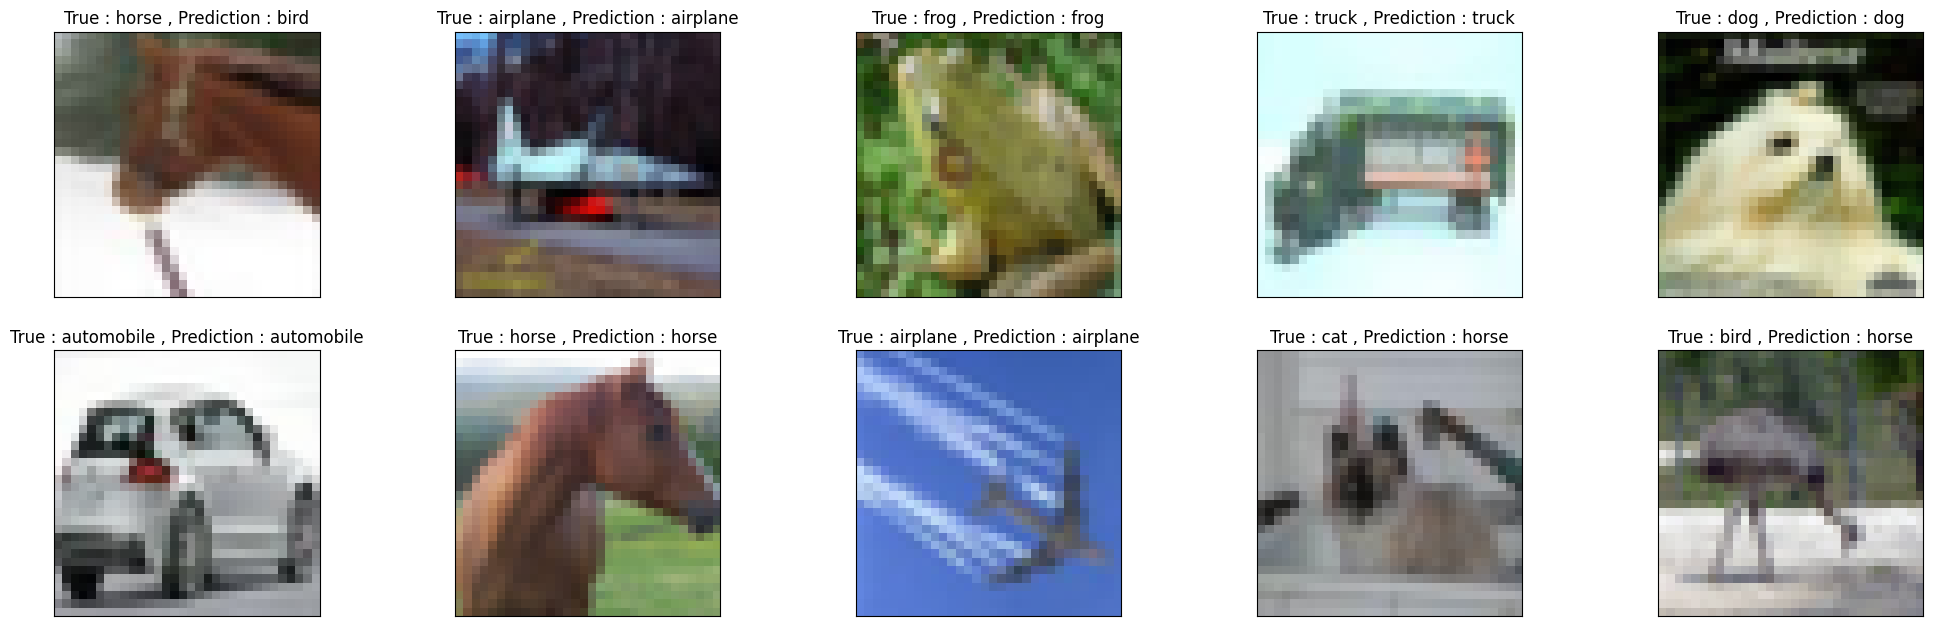

In [21]:
dataset, metadata = tfds.load('cifar10', as_supervised=True, with_info=True)
train, test = dataset['train'], dataset['test']
label_names = metadata.features['label'].names

validation_batches = test.batch(64)
pred = model.predict(validation_batches)
pred = np.argmax(pred,axis=1)
imgs = tf.concat([x for x,y in validation_batches],axis=0)
true = tf.concat([y for x,y in validation_batches],axis=0)

plt.figure(figsize=(25,20))
test.shuffle(buffer_size=1)
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.title(f"True : {label_names[true[i]]} , Prediction : {label_names[pred[i]]}")
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imgs[i], cmap=plt.cm.binary)
    
plt.show()